# Qualitative Comparison — All 3 Decoders, Same Images

**No training. Loads pretrained checkpoints and generates figures only.**

Required Kaggle dataset inputs:
- `wound-datasets` (test images + masks)
- `polar-v2-weights` (contains `best.pth` from Polar v2 run)
- `detr-extended-weights` (contains `best.pth` from DETR extended run)
- `autoregressive-extended-weights` (contains `best.pth` from Autoregressive extended run)

Runtime: ~2 minutes

In [1]:
import os, json, math, random, time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as T
import torchvision.models as models
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
import cv2
import warnings
warnings.filterwarnings('ignore')

assert torch.cuda.is_available(), 'No GPU! Select T4 x2 in Kaggle Settings.'
device = torch.device('cuda')
print(f'GPU: {torch.cuda.get_device_name(0)} | PyTorch: {torch.__version__}')

IMAGE_SIZE = 256
NUM_RADII_64 = 64
NUM_RADII_128 = 128
D_MODEL = 256
IMAGE_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'}
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]
MEAN_T = torch.tensor(MEAN).view(3,1,1)
STD_T  = torch.tensor(STD).view(3,1,1)

Path('figures').mkdir(exist_ok=True)
print('Setup complete.')

GPU: Tesla T4 | PyTorch: 2.10.0+cu128
Setup complete.


## 1. Load Test Images

In [2]:
_candidates = [
    Path('/kaggle/input/datasets/dianisay/wound-datasets/Datasets'),
    Path('/kaggle/input/wound-datasets/Datasets'),
    Path('/kaggle/input/datasets/dianisay/wound-datasets'),
    Path('/kaggle/input/wound-datasets'),
]
BASE_PATH = next((p for p in _candidates if p.exists()), _candidates[0])
print(f'BASE_PATH: {BASE_PATH} (exists={BASE_PATH.exists()})')

WOUND_DATASETS = [
    {'name': 'Medetec', 'root': BASE_PATH / 'Medetec_foot_ulcer_224',
     'splits': {'test': ('test/images', 'test/labels')}},
    {'name': 'AZH', 'root': BASE_PATH / 'wound_dataset' / 'azh_wound_care_center_dataset_patches',
     'splits': {'test': ('test/images', 'test/labels')}},
]

# Select FIRST 2 valid test images per dataset (deterministic, alphabetical)
fixed_images = []
for ds in WOUND_DATASETS:
    root = ds['root']
    if not root.exists():
        print(f'  {ds["name"]}: NOT FOUND at {root}')
        continue
    img_rel, lbl_rel = ds['splits']['test']
    img_dir = root / img_rel
    lbl_dir = root / lbl_rel
    if not img_dir.exists() or not lbl_dir.exists():
        print(f'  {ds["name"]}: dirs not found')
        continue
    imgs = sorted([p for p in img_dir.iterdir() if p.suffix.lower() in IMAGE_EXTS])
    lbl_files = {p.stem.lower(): p for p in lbl_dir.iterdir() if p.suffix.lower() in IMAGE_EXTS}
    count = 0
    for img_p in imgs:
        if count >= 2: break
        mask_p = lbl_files.get(img_p.stem.lower())
        if not mask_p: continue
        raw_mask = np.array(Image.open(mask_p).convert('L').resize((IMAGE_SIZE, IMAGE_SIZE), Image.NEAREST))
        if raw_mask.max() <= 1: raw_mask = raw_mask * 255
        gt_bin = (raw_mask > 127).astype(np.uint8)
        if gt_bin.sum() < 50: continue
        img_pil = Image.open(img_p).convert('RGB').resize((IMAGE_SIZE, IMAGE_SIZE))
        img_np = np.array(img_pil)
        img_t = torch.from_numpy(img_np.copy()).float().permute(2,0,1) / 255.0
        img_t = T.Normalize(MEAN, STD)(img_t)
        fixed_images.append({'ds_name': ds['name'], 'image': img_t, 'raw_mask': gt_bin, 'filename': img_p.name})
        count += 1
    print(f'  {ds["name"]}: {count} images selected')

print(f'\nTotal fixed images: {len(fixed_images)}')
print(f'Filenames: {[f["filename"] for f in fixed_images]}')

BASE_PATH: /kaggle/input/datasets/dianisay/wound-datasets/Datasets (exists=True)
  Medetec: 2 images selected
  AZH: 2 images selected

Total fixed images: 4
Filenames: ['foot-ulcer-0027.png', 'foot-ulcer-0027_1.png', 'b23232898bafcf304b2138af86be40b9_0.png', 'b586407933e66b112820f28448783627_0.png']


## 2. Model Architectures (inference only)

In [3]:
# ── Shared Encoder (backbone + 1x1 proj + transformer encoder) ──
class CNNTransformerEncoder(nn.Module):
    def __init__(self, d_model=D_MODEL, nhead=8, num_layers=2):
        super().__init__()
        backbone = models.resnet50(weights=None)
        self.backbone = nn.Sequential(
            backbone.conv1, backbone.bn1, backbone.relu, backbone.maxpool,
            backbone.layer1, backbone.layer2, backbone.layer3)
        self.proj = nn.Conv2d(1024, d_model, 1)
        self.pos_embed = nn.Parameter(torch.randn(1, 256, d_model) * 0.02)
        enc_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead,
            dim_feedforward=d_model*4, dropout=0.1, batch_first=True)
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=num_layers)

    def forward(self, x):
        feat = self.proj(self.backbone(x))
        tokens = feat.flatten(2).transpose(1, 2)
        tokens = tokens + self.pos_embed[:, :tokens.size(1)]
        return self.transformer(tokens)


# ── DETR Decoder (3 transformer decoder layers, Embedding queries) ──
class DETRDecoder(nn.Module):
    def __init__(self, d_model=D_MODEL, num_radii=NUM_RADII_64, nhead=8, num_layers=3):
        super().__init__()
        self.num_radii = num_radii
        self.register_buffer('_angles', torch.linspace(0, 2*math.pi, num_radii))
        self.queries = nn.Embedding(num_radii + 1, d_model)
        dec_layer = nn.TransformerDecoderLayer(d_model=d_model, nhead=nhead,
            dim_feedforward=d_model*4, dropout=0.1, batch_first=True)
        self.transformer = nn.TransformerDecoder(dec_layer, num_layers=num_layers)
        self.centroid_head = nn.Linear(d_model, 2)
        self.radii_head = nn.Linear(d_model, 1)
        self.point_head = nn.Linear(d_model, 2)

    def forward(self, memory):
        B = memory.size(0)
        q = self.queries.weight.unsqueeze(0).expand(B, -1, -1)
        out = self.transformer(q, memory)
        cx_cy = torch.sigmoid(self.centroid_head(out[:, -1]))
        r = torch.sigmoid(self.radii_head(out[:, :self.num_radii])).squeeze(-1) * 0.7
        ang = self._angles.unsqueeze(0)
        px = cx_cy[:, 0:1] + r * torch.cos(ang)
        py = cx_cy[:, 1:2] + r * torch.sin(ang)
        return {'centroid': cx_cy, 'radii': r, 'points': torch.stack([px, py], dim=-1)}


# ── Autoregressive Decoder (GRU-based) ──
class AutoregressiveDecoder(nn.Module):
    def __init__(self, d_model=D_MODEL, num_radii=NUM_RADII_64, hidden_size=512):
        super().__init__()
        self.num_radii = num_radii
        self.hidden_size = hidden_size
        self.register_buffer('_angles', torch.linspace(0, 2*math.pi, num_radii))
        self.context = nn.Linear(d_model, hidden_size)
        self.gru = nn.GRUCell(1, hidden_size)
        self.out_head = nn.Linear(hidden_size, 1)
        self.centroid_head = nn.Sequential(
            nn.Linear(d_model, 128), nn.ReLU(), nn.Linear(128, 2))

    def forward(self, memory):
        B = memory.size(0)
        global_feat = memory.mean(dim=1)
        cx_cy = torch.sigmoid(self.centroid_head(global_feat))
        h = torch.relu(self.context(global_feat))
        radii = []
        r_i = torch.zeros(B, 1, device=memory.device)
        for i in range(self.num_radii):
            h = self.gru(r_i, h)
            r_i = torch.sigmoid(self.out_head(h)) * 0.7
            radii.append(r_i)
        r = torch.cat(radii, dim=1)
        ang = self._angles.unsqueeze(0)
        px = cx_cy[:, 0:1] + r * torch.cos(ang)
        py = cx_cy[:, 1:2] + r * torch.sin(ang)
        return {'centroid': cx_cy, 'radii': r, 'points': torch.stack([px, py], dim=-1)}


# ── Per-Angle Attention Decoder (Polar v2, 128 radii) ──
class PerAngleAttentionDecoder(nn.Module):
    def __init__(self, d_model=D_MODEL, nhead=8, num_radii=NUM_RADII_128, num_layers=2):
        super().__init__()
        self.num_radii = num_radii
        self.queries = nn.Parameter(torch.randn(1, num_radii+1, d_model)*0.02)
        angles = torch.arange(num_radii).float()*(2*math.pi/num_radii)
        ang_enc = torch.stack([angles.cos(), angles.sin()], dim=-1)
        ang_enc_full = torch.zeros(num_radii+1, d_model)
        ang_enc_full[:num_radii, :2] = ang_enc
        self.register_buffer('ang_encoding', ang_enc_full.unsqueeze(0))
        dec_layer = nn.TransformerDecoderLayer(d_model=d_model, nhead=nhead,
            dim_feedforward=d_model*4, dropout=0.1, batch_first=True)
        self.cross_attn = nn.TransformerDecoder(dec_layer, num_layers=num_layers)
        self.centroid_head = nn.Sequential(nn.Linear(d_model,128), nn.ReLU(), nn.Linear(128,2))
        self.radii_head = nn.Sequential(nn.Linear(d_model,128), nn.ReLU(), nn.Linear(128,1))
        self._angles = nn.Parameter(torch.arange(num_radii).float()*(2*math.pi/num_radii), requires_grad=False)

    def forward(self, memory):
        B = memory.size(0)
        q = (self.queries + self.ang_encoding).expand(B,-1,-1)
        out = self.cross_attn(q, memory)
        cx_cy = torch.sigmoid(self.centroid_head(out[:,-1]))
        r = torch.sigmoid(self.radii_head(out[:,:-1])).squeeze(-1)*0.7
        ang = self._angles.unsqueeze(0)
        px = cx_cy[:,0:1] + r*torch.cos(ang)
        py = cx_cy[:,1:2] + r*torch.sin(ang)
        return {'centroid': cx_cy, 'radii': r, 'points': torch.stack([px,py], dim=-1)}


class FourierDescriptorHead(nn.Module):
    def __init__(self, d_model=D_MODEL, n_coeffs=32, num_radii=NUM_RADII_128):
        super().__init__()
        self.n_coeffs = n_coeffs
        self.head = nn.Sequential(nn.Linear(d_model,256), nn.ReLU(), nn.Dropout(0.1), nn.Linear(256, 2*n_coeffs))
        t = torch.arange(num_radii).float()*(2*math.pi/num_radii)
        k = torch.arange(n_coeffs).float()
        self.register_buffer('cos_basis', torch.cos(t.unsqueeze(1)*k.unsqueeze(0)))
        self.register_buffer('sin_basis', torch.sin(t.unsqueeze(1)*k.unsqueeze(0)))

    def forward(self, global_feat):
        coeffs = self.head(global_feat)
        a, b = coeffs[:,:self.n_coeffs], coeffs[:,self.n_coeffs:]
        return torch.sigmoid(a @ self.cos_basis.T + b @ self.sin_basis.T)*0.7


class PolarModelV2(nn.Module):
    def __init__(self, d_model=D_MODEL, num_radii=NUM_RADII_128):
        super().__init__()
        self.encoder = CNNTransformerEncoder(d_model=d_model)
        self.decoder = PerAngleAttentionDecoder(d_model=d_model, num_radii=num_radii)
        self.fourier_head = FourierDescriptorHead(d_model=d_model, n_coeffs=32, num_radii=num_radii)

    def forward(self, x):
        memory = self.encoder(x)
        polar_out = self.decoder(memory)
        polar_out['fourier_radii'] = self.fourier_head(memory.mean(dim=1))
        return polar_out

print('All architectures defined (matching trained checkpoints).')

All architectures defined (matching trained checkpoints).


## 3. Load Checkpoints

In [4]:
# Checkpoint search
def find_checkpoint(name, candidates):
    for p in candidates:
        if p.exists():
            print(f'  {name}: {p}')
            return p
    print(f'  {name}: NOT FOUND')
    return None

print('Searching for checkpoints...')
polar_ckpt = find_checkpoint('Polar v2', [
    Path('/kaggle/input/datasets/dianisay/trainedmodels/Models/Polar/best.pth'),
    Path('/kaggle/input/polar-v2-weights/best.pth'),
])
detr_ckpt = find_checkpoint('DETR', [
    Path('/kaggle/input/datasets/dianisay/trainedmodels/Models/DETR/best.pth'),
    Path('/kaggle/input/detr-extended-weights/best.pth'),
])
ar_ckpt = find_checkpoint('Autoregressive', [
    Path('/kaggle/input/datasets/dianisay/trainedmodels/Models/Autoregressive/best.pth'),
    Path('/kaggle/input/autoregressive-extended-weights/best.pth'),
])


Searching for checkpoints...
  Polar v2: /kaggle/input/datasets/dianisay/trainedmodels/Models/Polar/best.pth
  DETR: /kaggle/input/datasets/dianisay/trainedmodels/Models/DETR/best.pth
  Autoregressive: /kaggle/input/datasets/dianisay/trainedmodels/Models/Autoregressive/best.pth


In [5]:
# ── Load pretrained models ──
models_loaded = []

# Polar v2 - loads full model from 'model_state'
if polar_ckpt:
    polar_model = PolarModelV2().to(device)
    ck = torch.load(polar_ckpt, map_location=device, weights_only=False)
    polar_model.load_state_dict(ck['model_state'])
    polar_model.eval()
    models_loaded.append(('Polar v2 (ours)', polar_model, 'polar_v2'))
    print(f'  Polar v2 loaded (epoch {ck.get("epoch", "?")})')

# DETR - loads encoder_state + decoder_state separately
if detr_ckpt:
    enc_detr = CNNTransformerEncoder().to(device)
    dec_detr = DETRDecoder().to(device)
    ck = torch.load(detr_ckpt, map_location=device, weights_only=False)
    enc_detr.load_state_dict(ck['encoder_state'])
    dec_detr.load_state_dict(ck['decoder_state'])
    enc_detr.eval(); dec_detr.eval()
    models_loaded.append(('DETR Decoder', (enc_detr, dec_detr), 'detr'))
    print(f'  DETR loaded (epoch {ck.get("epoch", "?")})')

# Autoregressive - loads encoder_state + decoder_state separately
if ar_ckpt:
    enc_ar = CNNTransformerEncoder().to(device)
    dec_ar = AutoregressiveDecoder().to(device)
    ck = torch.load(ar_ckpt, map_location=device, weights_only=False)
    enc_ar.load_state_dict(ck['encoder_state'])
    dec_ar.load_state_dict(ck['decoder_state'])
    enc_ar.eval(); dec_ar.eval()
    models_loaded.append(('Autoregressive', (enc_ar, dec_ar), 'autoregressive'))
    print(f'  Autoregressive loaded (epoch {ck.get("epoch", "?")})')

print(f'\nLoaded {len(models_loaded)} models total.')

  Polar v2 loaded (epoch 47)
  DETR loaded (epoch 30)
  Autoregressive loaded (epoch 13)

Loaded 3 models total.


## 4. Generate Combined Figure

Generating 3 x 4 comparison figure...


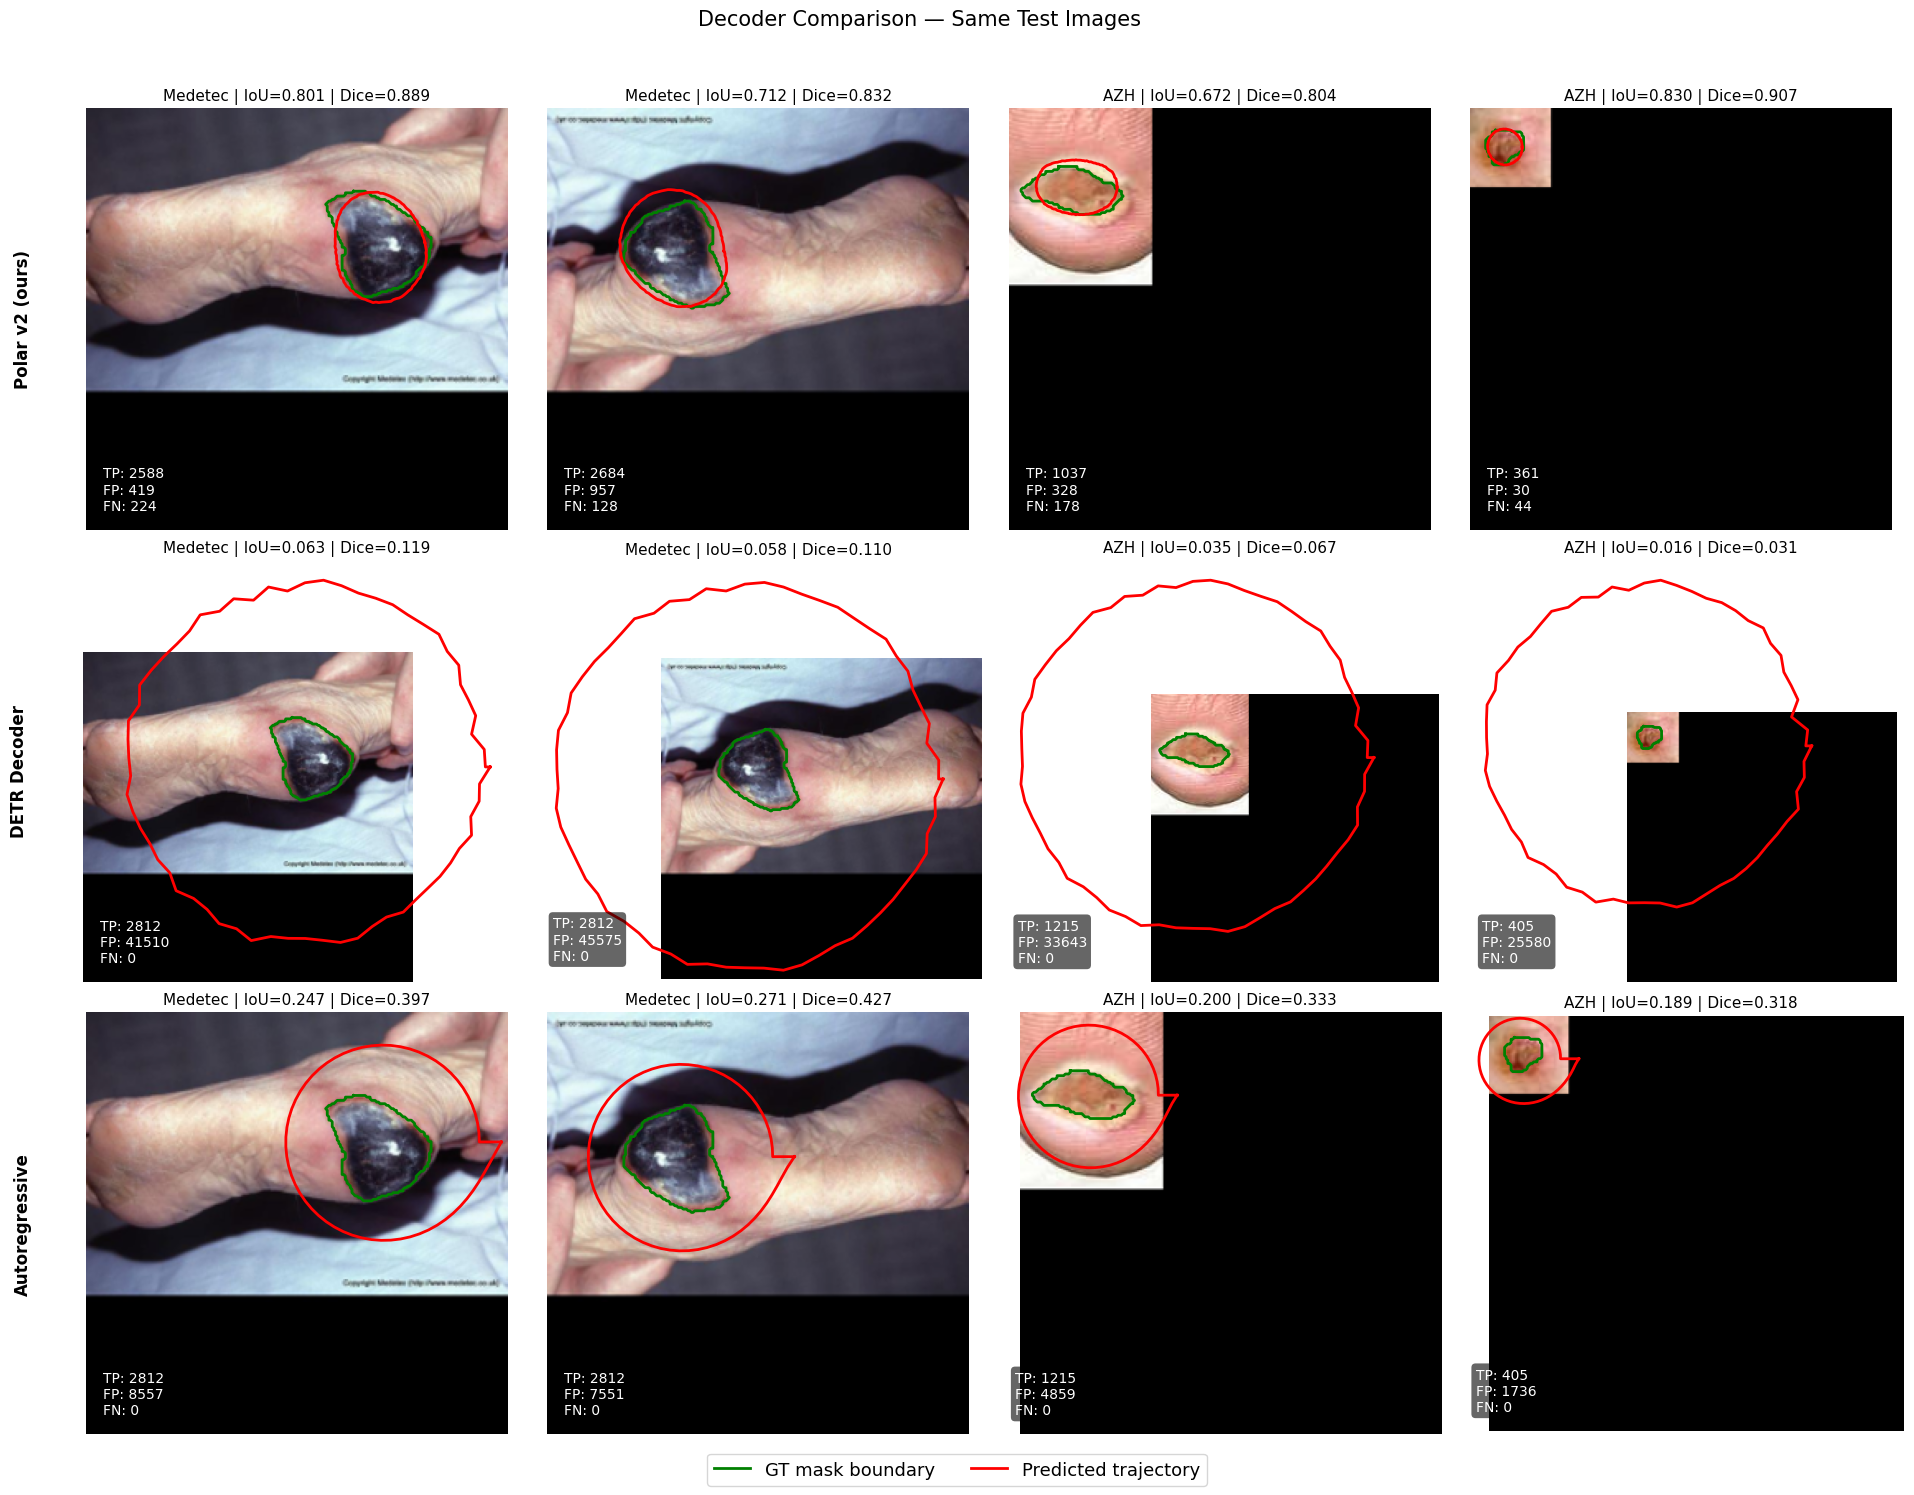

Saved: figures/combined_decoder_comparison.png


In [6]:
def predict_contour(model_entry, img_t):
    """Run inference and return points in pixel coordinates."""
    name, model_or_tuple, mtype = model_entry
    with torch.no_grad():
        if mtype == 'polar_v2':
            pred = model_or_tuple(img_t.unsqueeze(0).to(device))
        else:
            enc, dec = model_or_tuple
            mem = enc(img_t.unsqueeze(0).to(device))
            pred = dec(mem)
    return pred['points'][0].cpu().numpy() * IMAGE_SIZE


n_models = len(models_loaded)
n_images = len(fixed_images)
print(f'Generating {n_models} x {n_images} comparison figure...')

fig, axes = plt.subplots(n_models, n_images, figsize=(5*n_images, 5*n_models))
if n_models == 1: axes = axes.reshape(1, -1)
if n_images == 1: axes = axes.reshape(-1, 1)

for row, model_entry in enumerate(models_loaded):
    mname = model_entry[0]
    for col, fimg in enumerate(fixed_images):
        ax = axes[row, col]
        img_show = (fimg['image'] * STD_T + MEAN_T).permute(1,2,0).numpy().clip(0,1)
        ax.imshow(img_show)

        # GT mask contour (green)
        contours_gt, _ = cv2.findContours(fimg['raw_mask'], cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        for cnt in contours_gt:
            pts_c = cnt.squeeze()
            if len(pts_c.shape) == 2 and len(pts_c) > 2:
                ax.plot(np.append(pts_c[:,0], pts_c[0,0]), np.append(pts_c[:,1], pts_c[0,1]),
                        'g-', linewidth=2)

        # Predicted trajectory (red)
        pts = predict_contour(model_entry, fimg['image'])
        ax.plot(np.append(pts[:,0], pts[0,0]), np.append(pts[:,1], pts[0,1]),
                'r-', linewidth=2)

        # ---------------------------------------------------------
        # MÉTRICAS: IoU, Dice, TP, FP, FN
        # ---------------------------------------------------------
        pred_mask = np.zeros((IMAGE_SIZE, IMAGE_SIZE), np.uint8)
        cv2.fillPoly(pred_mask, [pts.astype(np.int32)], 1)
        
        gt_mask = fimg['raw_mask']
        
        # True Positives (Intersección)
        tp = float((pred_mask & gt_mask).sum())
        
        # False Positives y False Negatives
        fp = float(pred_mask.sum()) - tp
        fn = float(gt_mask.sum()) - tp
        
        # Intersección sobre Unión (IoU) y Coeficiente Dice
        union = tp + fp + fn
        iou = tp / union if union > 0 else 0
        dice = (2 * tp) / (2 * tp + fp + fn) if (2 * tp + fp + fn) > 0 else 0

        # Actualizamos el título para incluir ambas métricas principales
        ax.set_title(f"{fimg['ds_name']} | IoU={iou:.3f} | Dice={dice:.3f}", fontsize=11)
        ax.axis('off')
        
        # Añadir caja de texto flotante con TP, FP, FN tipo matriz de confusión
        metrics_text = f"TP: {int(tp)}\nFP: {int(fp)}\nFN: {int(fn)}"
        ax.text(0.04, 0.04, metrics_text, transform=ax.transAxes,
                fontsize=10, color='white', verticalalignment='bottom',
                bbox=dict(facecolor='black', alpha=0.6, edgecolor='none', boxstyle='round,pad=0.3'))
        # ---------------------------------------------------------

    # Row label
    axes[row, 0].annotate(mname, xy=(-0.15, 0.5), xycoords='axes fraction',
        fontsize=12, fontweight='bold', ha='center', va='center', rotation=90)

fig.legend(['GT mask boundary', 'Predicted trajectory'], loc='lower center', ncol=2, fontsize=13)
plt.suptitle('Decoder Comparison — Same Test Images', fontsize=15, y=0.99)
plt.tight_layout(rect=[0.04, 0.03, 1, 0.97])
plt.savefig('figures/combined_decoder_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/combined_decoder_comparison.png')

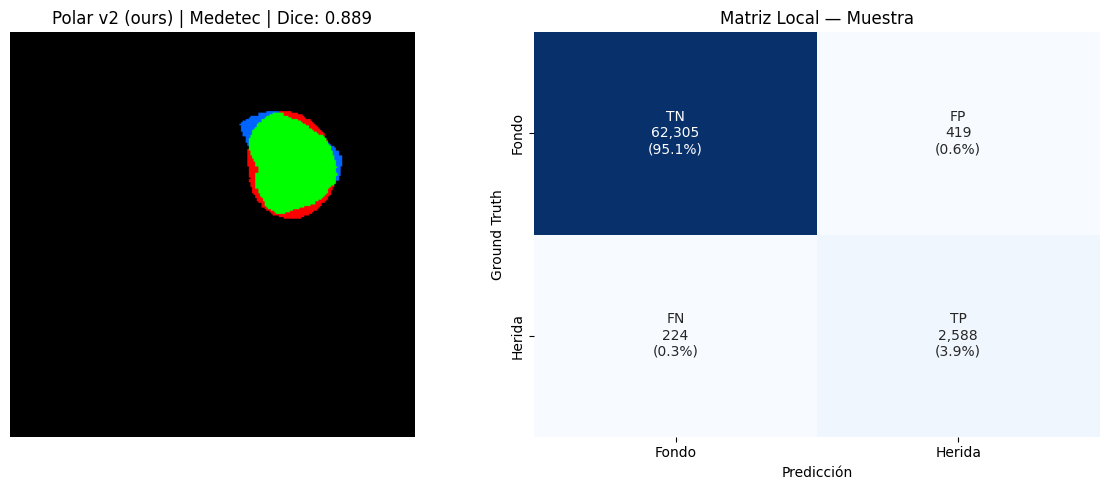

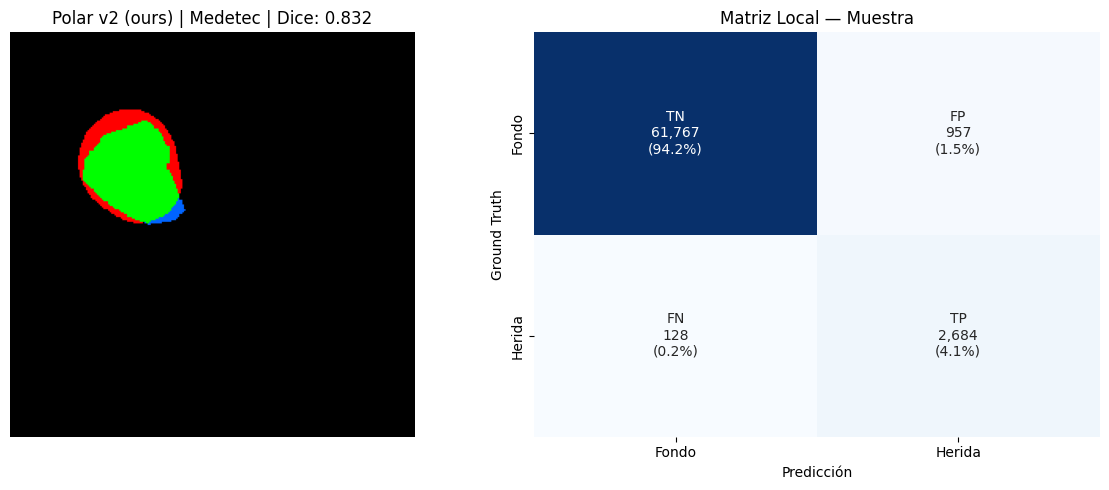

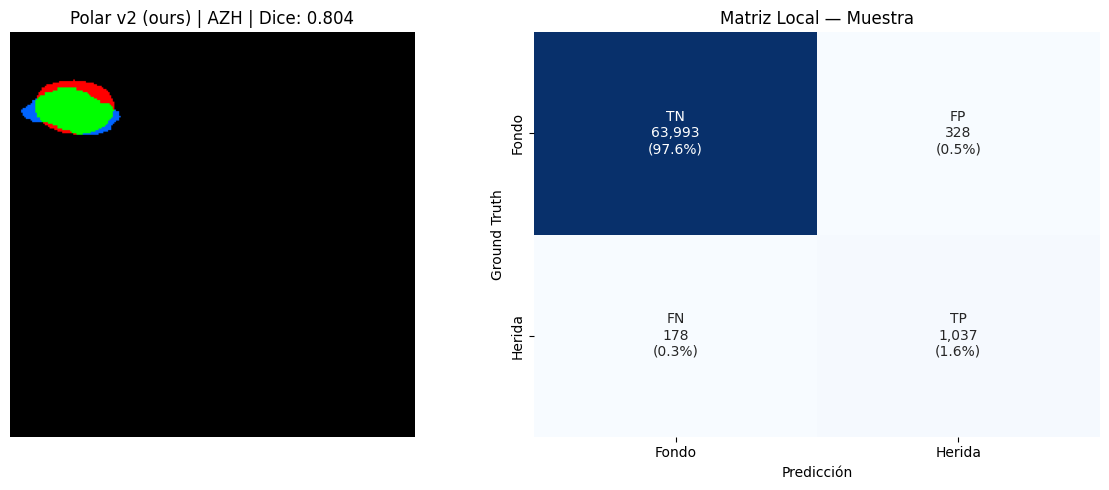

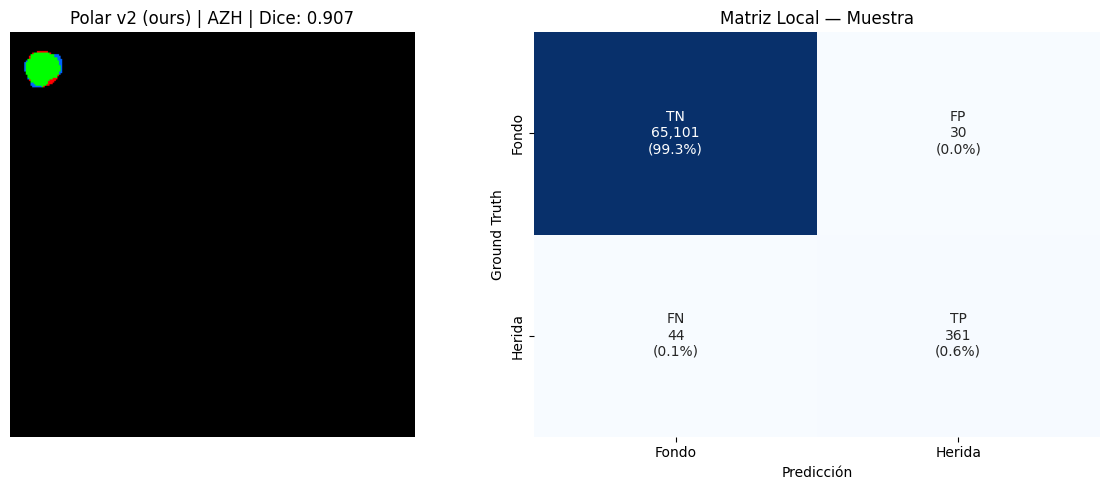

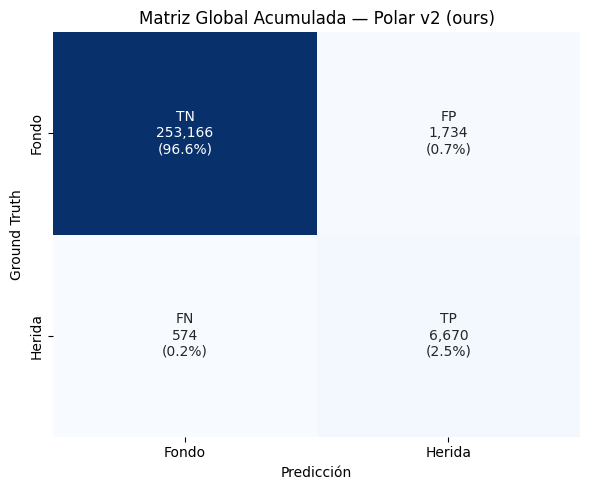

Completado e imágenes guardadas para modelo: Polar v2 (ours)


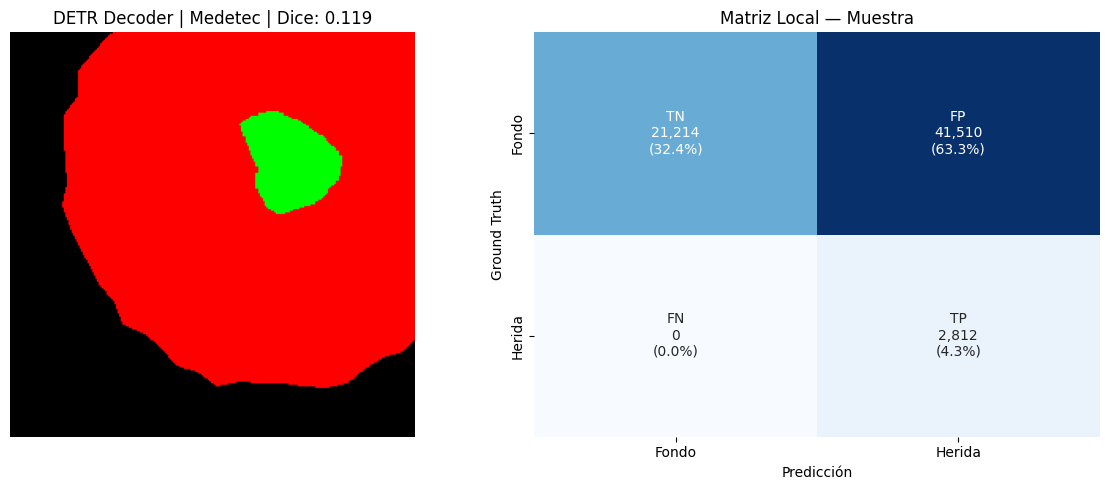

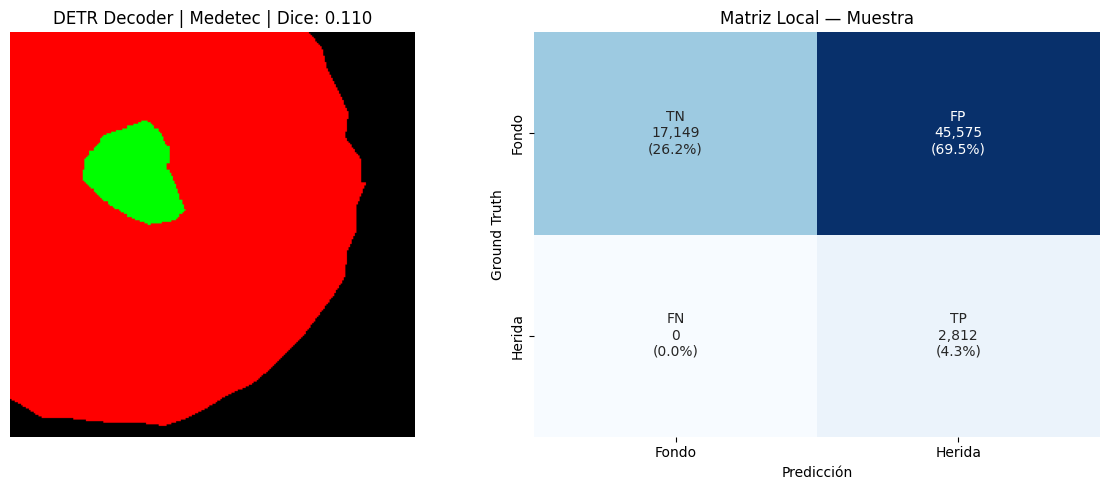

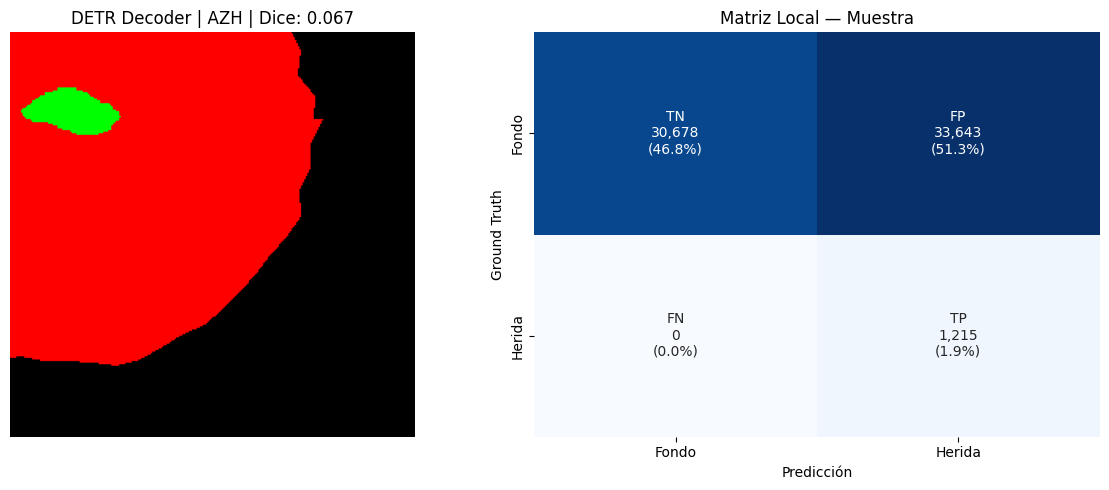

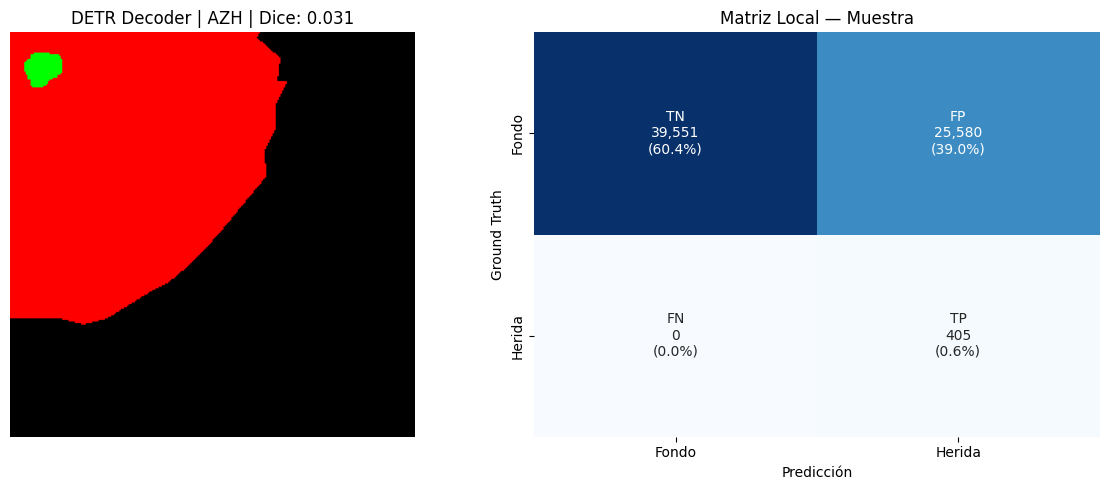

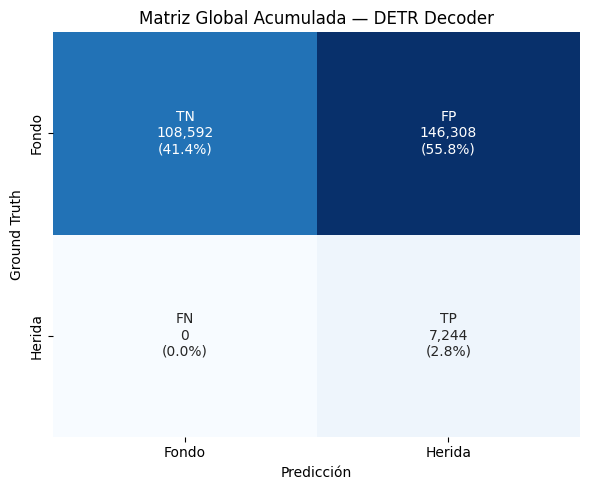

Completado e imágenes guardadas para modelo: DETR Decoder


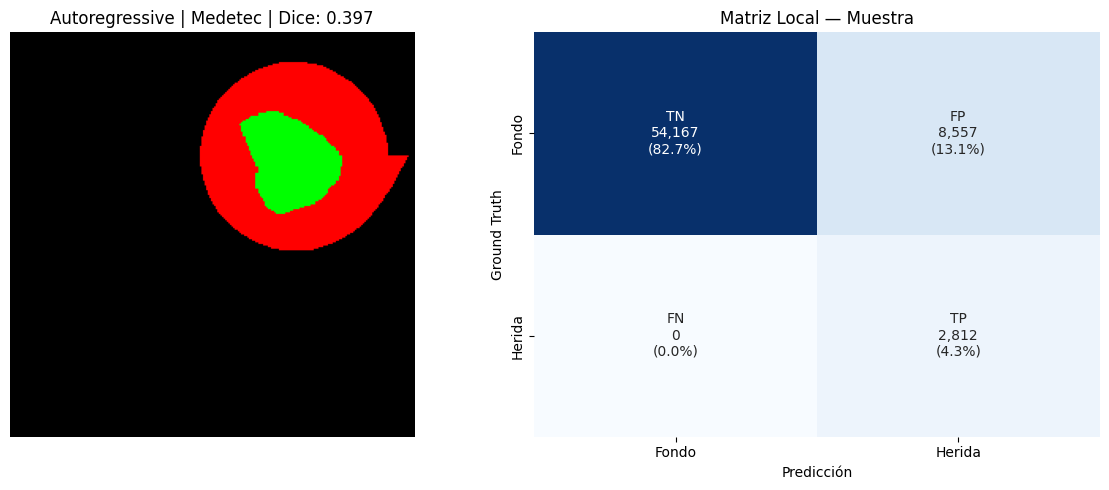

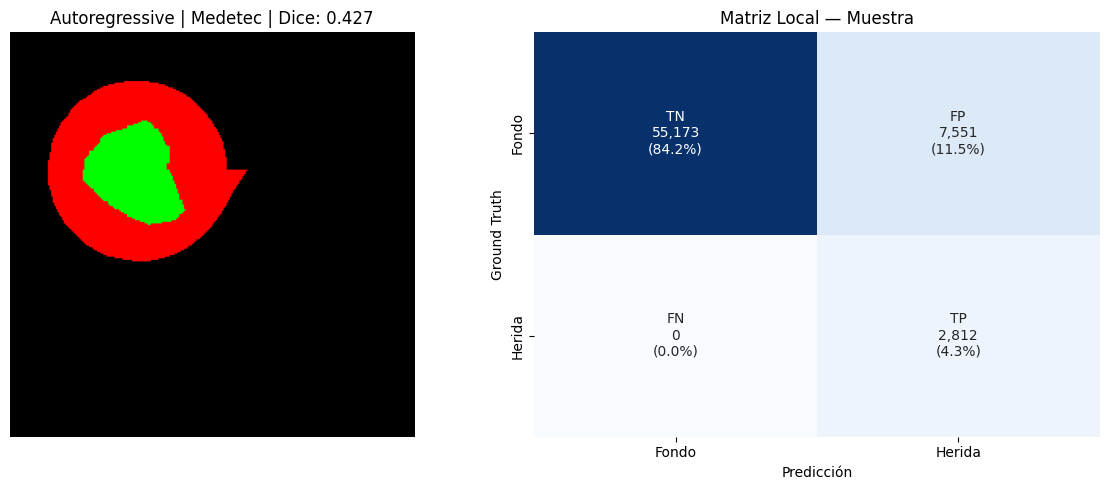

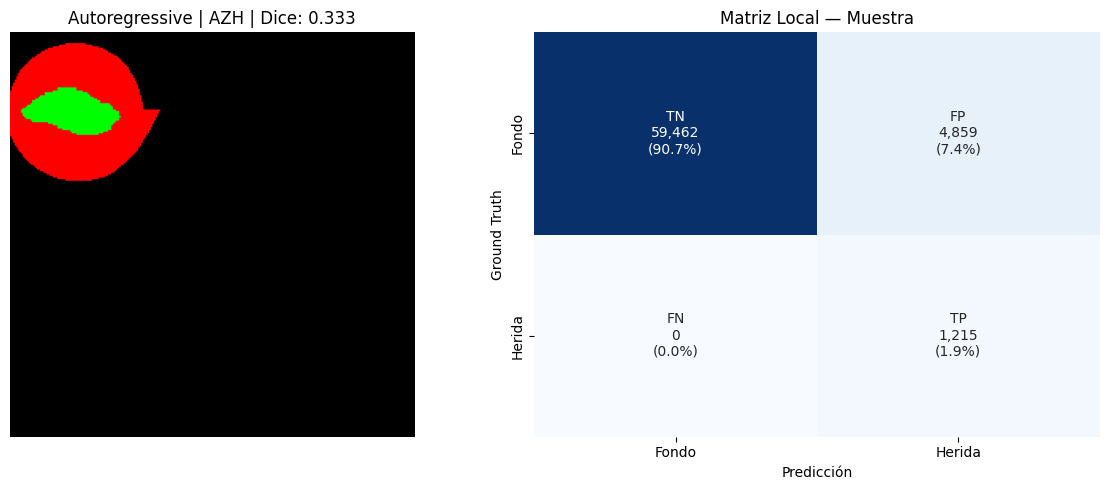

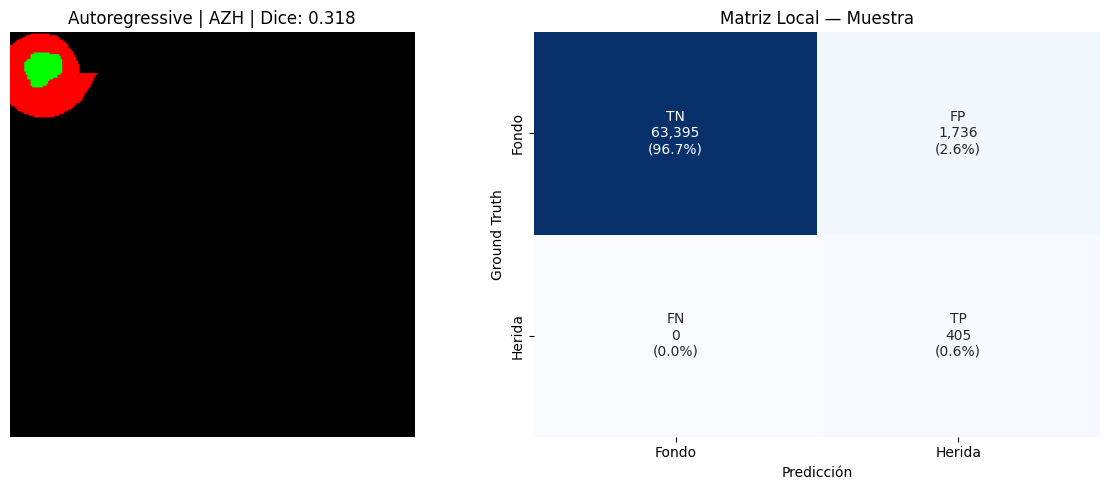

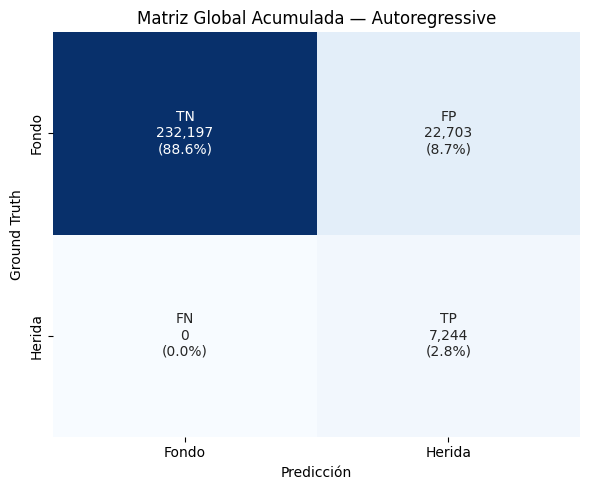

Completado e imágenes guardadas para modelo: Autoregressive


In [7]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns

def generate_error_map(pred_mask, gt_mask):
    """Generando la máscara RGB con errores espaciales (Verde=TP, Rojo=FP, Azul=FN)."""
    h, w = pred_mask.shape
    error_map = np.zeros((h, w, 3), dtype=np.uint8)
    
    tp_mask = (pred_mask == 1) & (gt_mask == 1)
    fp_mask = (pred_mask == 1) & (gt_mask == 0)
    fn_mask = (pred_mask == 0) & (gt_mask == 1)
    
    error_map[tp_mask] = [0, 255, 0]   # Verde -> TP
    error_map[fp_mask] = [255, 0, 0]   # Rojo  -> FP
    error_map[fn_mask] = [0, 100, 255] # Azul  -> FN
    return error_map

def plot_confusion_matrix(ax, tp, fp, fn, tn, title='Matriz de Confusión (Píxeles)'):
    """Dibujando el heatmap 2x2 de la matriz de confusión con porcentajes."""
    cm = np.array([[tn, fp], [fn, tp]])
    total = cm.sum()
    cm_perc = (cm / total * 100) if total > 0 else cm
    
    labels = np.array([
        [f"TN\n{int(tn):,}\n({cm_perc[0,0]:.1f}%)", f"FP\n{int(fp):,}\n({cm_perc[0,1]:.1f}%)"],
        [f"FN\n{int(fn):,}\n({cm_perc[1,0]:.1f}%)", f"TP\n{int(tp):,}\n({cm_perc[1,1]:.1f}%)"]
    ])
    
    sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['Fondo', 'Herida'], yticklabels=['Fondo', 'Herida'])
    ax.set_xlabel('Predicción')
    ax.set_ylabel('Ground Truth')
    ax.set_title(title)

# ---------------------------------------------------------
# BUCLE PRINCIPAL DE EVALUACIÓN INDIVIDUAL Y GLOBAL
# ---------------------------------------------------------
for model_entry in models_loaded:
    mname, _, mtype = model_entry
    
    # Acumuladores de píxeles para la matriz global del modelo
    global_tp = 0.0
    global_fp = 0.0
    global_fn = 0.0
    global_tn = 0.0
    
    for fimg in fixed_images:
        # 1. Obtener contorno predicho y convertir a máscara
        pts = predict_contour(model_entry, fimg['image'])
        pred_mask = np.zeros((IMAGE_SIZE, IMAGE_SIZE), np.uint8)
        cv2.fillPoly(pred_mask, [pts.astype(np.int32)], 1)
        gt_mask = fimg['raw_mask']
        
        # 2. Conteo de píxeles por región
        tp = float((pred_mask & gt_mask).sum())
        fp = float(pred_mask.sum()) - tp
        fn = float(gt_mask.sum()) - tp
        tn = float((IMAGE_SIZE * IMAGE_SIZE) - (tp + fp + fn))
        
        # 3. Sumar a la métrica acumulada global
        global_tp += tp
        global_fp += fp
        global_fn += fn
        global_tn += tn
        
        # Dice local
        dice = (2 * tp) / (2 * tp + fp + fn) if (2 * tp + fp + fn) > 0 else 0
        
        # 4. Graficar par individual (Mapa Espacial + Matriz Local)
        fig, (ax_spatial, ax_cm) = plt.subplots(1, 2, figsize=(12, 5))
        
        # Panel izquierdo: Mapa de error en color
        spatial_cm = generate_error_map(pred_mask, gt_mask)
        ax_spatial.imshow(spatial_cm)
        ax_spatial.set_title(f"{mname} | {fimg['ds_name']} | Dice: {dice:.3f}")
        ax_spatial.axis('off')
        
        # Panel derecho: Matriz local
        plot_confusion_matrix(ax_cm, tp, fp, fn, tn, title=f"Matriz Local — Muestra")
        
        plt.tight_layout()
        plt.savefig(f"figures/spatial_cm_{mtype}_{fimg['ds_name']}.png", dpi=150, bbox_inches='tight')
        plt.show()
        plt.close(fig)
        
    # 5. Graficar Matriz GLOBAL Acumulada para este modelo
    fig_global, ax_global = plt.subplots(figsize=(6, 5))
    plot_confusion_matrix(ax_global, global_tp, global_fp, global_fn, global_tn, 
                          title=f"Matriz Global Acumulada — {mname}")
    plt.tight_layout()
    plt.savefig(f"figures/global_cm_{mtype}.png", dpi=150, bbox_inches='tight')
    plt.show()
    plt.close(fig_global)
    
    print(f"Completado e imágenes guardadas para modelo: {mname}")

## 5. Individual Figures (one per decoder)

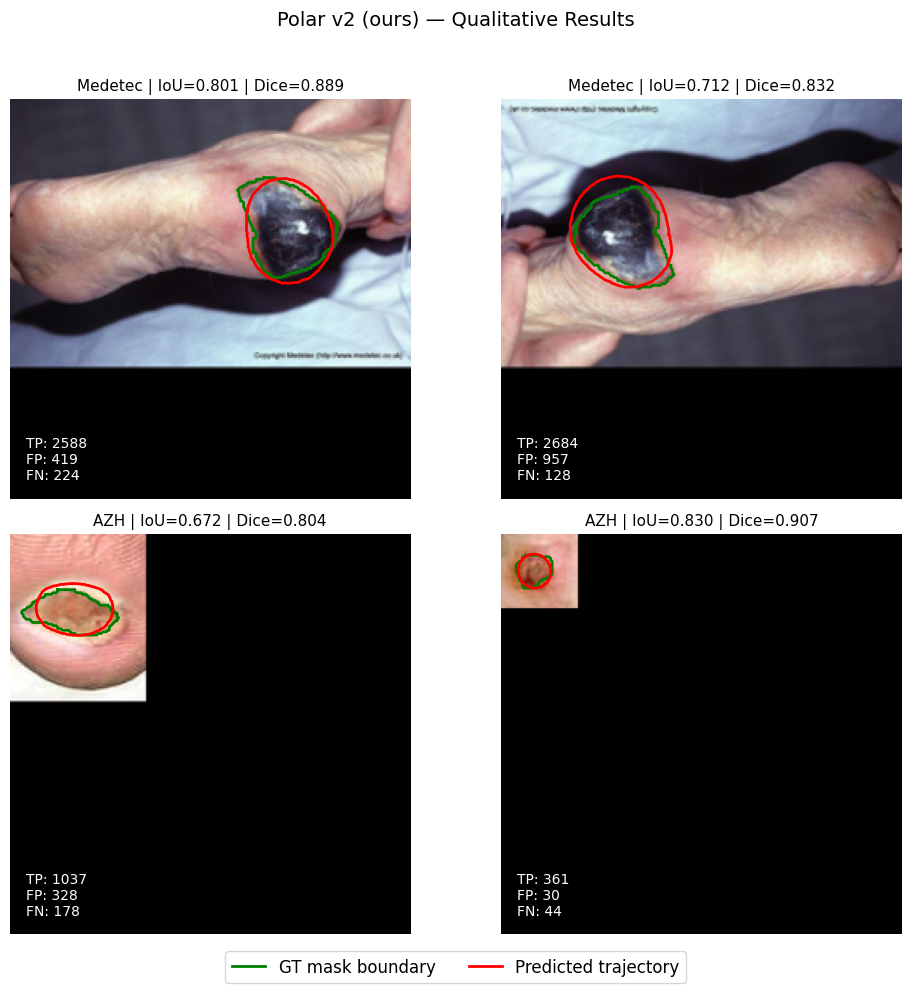

Saved: figures/qualitative_polar_v2.png


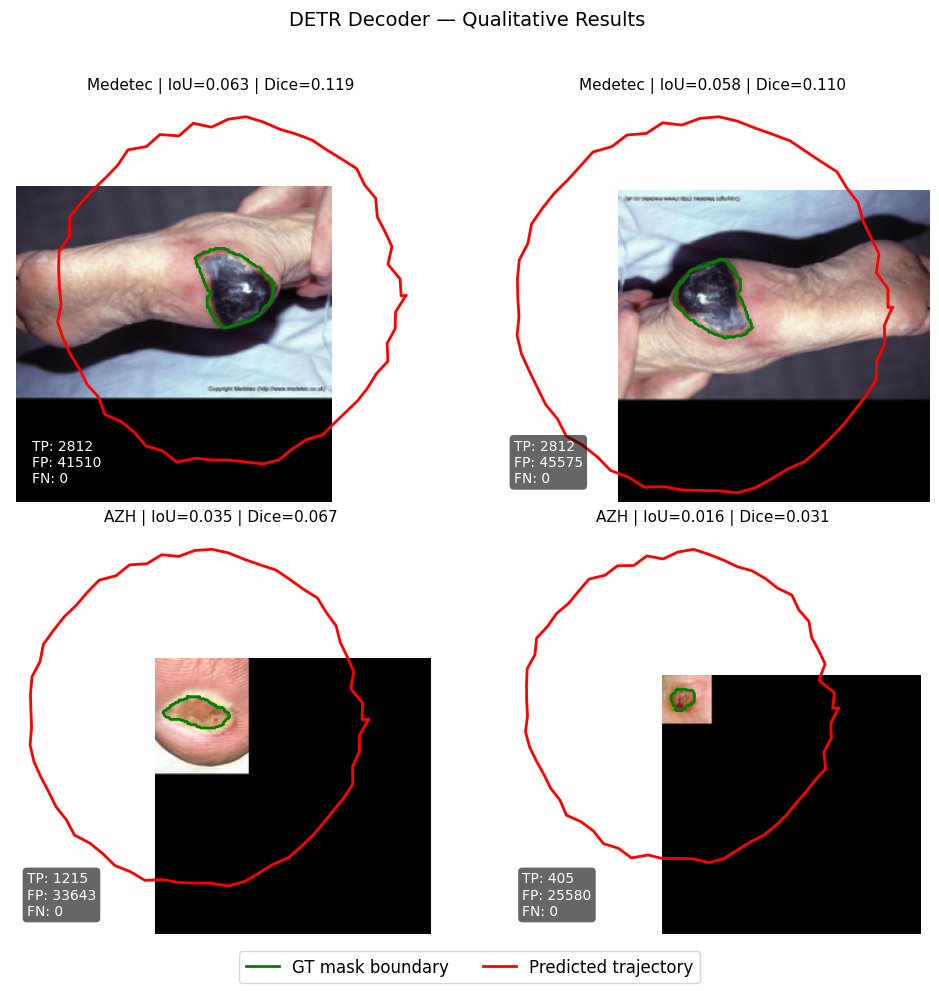

Saved: figures/qualitative_detr.png


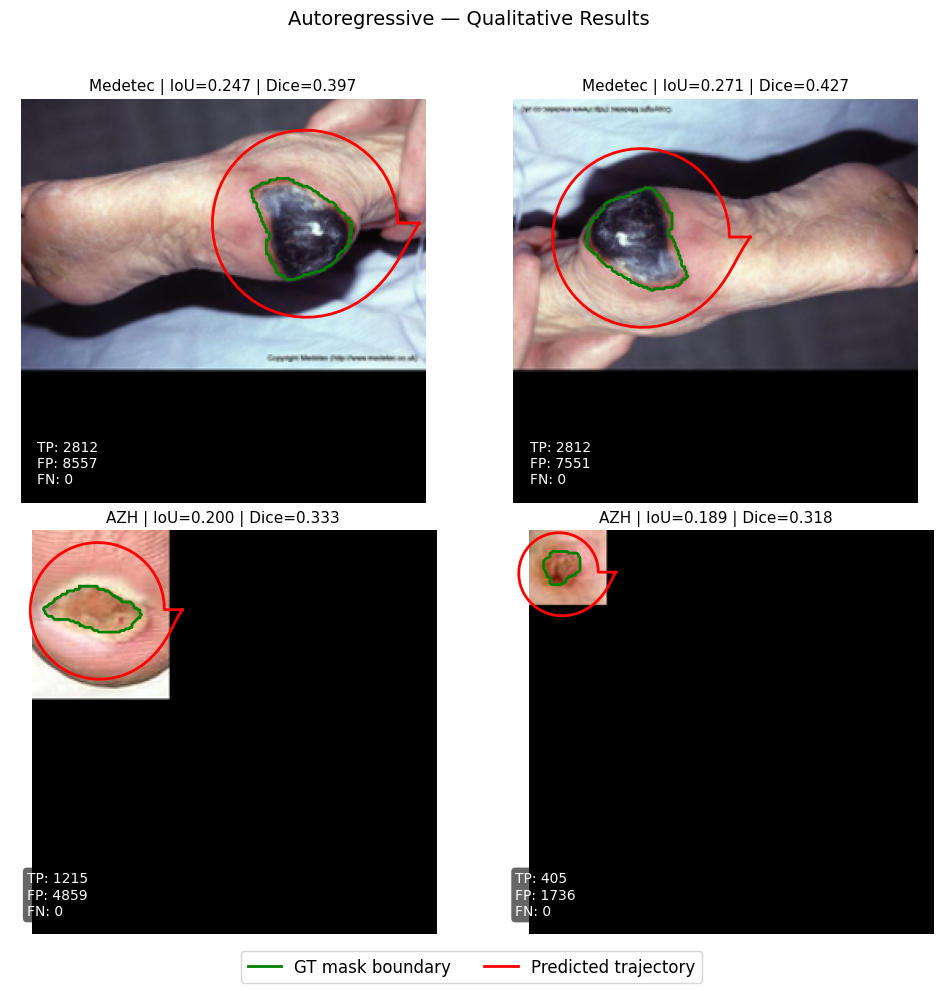

Saved: figures/qualitative_autoregressive.png


In [8]:
# Also generate individual 2x2 figures (same style as the Polar v2 one)
for model_entry in models_loaded:
    mname, _, mtype = model_entry
    n = min(len(fixed_images), 4)
    cols = 2
    rows = (n + 1) // 2
    fig, axes = plt.subplots(rows, cols, figsize=(10, 5*rows))
    axes_flat = axes.flatten() if n > 1 else [axes]

    for i, fimg in enumerate(fixed_images[:n]):
        ax = axes_flat[i]
        img_show = (fimg['image'] * STD_T + MEAN_T).permute(1,2,0).numpy().clip(0,1)
        ax.imshow(img_show)

        contours_gt, _ = cv2.findContours(fimg['raw_mask'], cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        for cnt in contours_gt:
            pts_c = cnt.squeeze()
            if len(pts_c.shape) == 2 and len(pts_c) > 2:
                ax.plot(np.append(pts_c[:,0], pts_c[0,0]), np.append(pts_c[:,1], pts_c[0,1]),
                        'g-', linewidth=2)

        pts = predict_contour(model_entry, fimg['image'])
        ax.plot(np.append(pts[:,0], pts[0,0]), np.append(pts[:,1], pts[0,1]), 'r-', linewidth=2)

        # ---------------------------------------------------------
        # CÁLCULO DE MÉTRICAS: IoU, Dice, TP, FP, FN
        # ---------------------------------------------------------
        pred_mask = np.zeros((IMAGE_SIZE, IMAGE_SIZE), np.uint8)
        cv2.fillPoly(pred_mask, [pts.astype(np.int32)], 1)
        gt_mask = fimg['raw_mask']

        # Conteo de píxeles por región
        tp = float((pred_mask & gt_mask).sum())
        fp = float(pred_mask.sum()) - tp
        fn = float(gt_mask.sum()) - tp

        # Métricas IoU y Dice
        union = tp + fp + fn
        iou = tp / union if union > 0 else 0
        dice = (2 * tp) / (2 * tp + fp + fn) if (2 * tp + fp + fn) > 0 else 0

        # Título con IoU y Dice
        ax.set_title(f"{fimg['ds_name']} | IoU={iou:.3f} | Dice={dice:.3f}", fontsize=11)
        ax.axis('off')

        # Matriz de confusión superpuesta (píxeles)
        metrics_text = f"TP: {int(tp)}\nFP: {int(fp)}\nFN: {int(fn)}"
        ax.text(0.04, 0.04, metrics_text, transform=ax.transAxes,
                fontsize=10, color='white', verticalalignment='bottom',
                bbox=dict(facecolor='black', alpha=0.6, edgecolor='none', boxstyle='round,pad=0.3'))
        # ---------------------------------------------------------

    for i in range(n, len(axes_flat)): axes_flat[i].set_visible(False)
    fig.legend(['GT mask boundary', 'Predicted trajectory'], loc='lower center', ncol=2, fontsize=12)
    plt.suptitle(f'{mname} — Qualitative Results', fontsize=14, y=0.98)
    plt.tight_layout(rect=[0, 0.04, 1, 0.96])
    plt.savefig(f'figures/qualitative_{mtype}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: figures/qualitative_{mtype}.png')

## 6. Summary

In [9]:
print('\n' + '='*60)
print('VISUALIZATION COMPLETE')
print('='*60)
print(f'Models evaluated: {[m[0] for m in models_loaded]}')
print(f'Images used: {[f["filename"] for f in fixed_images]}')
print(f'Datasets: {[f["ds_name"] for f in fixed_images]}')
print()
print('Output files:')
print('  figures/combined_decoder_comparison.png  (all decoders, same images)')
for _, _, mtype in models_loaded:
    print(f'  figures/qualitative_{mtype}.png  (individual 2x2)')
print()
print('All figures use the SAME test images for direct comparison.')


VISUALIZATION COMPLETE
Models evaluated: ['Polar v2 (ours)', 'DETR Decoder', 'Autoregressive']
Images used: ['foot-ulcer-0027.png', 'foot-ulcer-0027_1.png', 'b23232898bafcf304b2138af86be40b9_0.png', 'b586407933e66b112820f28448783627_0.png']
Datasets: ['Medetec', 'Medetec', 'AZH', 'AZH']

Output files:
  figures/combined_decoder_comparison.png  (all decoders, same images)
  figures/qualitative_polar_v2.png  (individual 2x2)
  figures/qualitative_detr.png  (individual 2x2)
  figures/qualitative_autoregressive.png  (individual 2x2)

All figures use the SAME test images for direct comparison.
